# What drives the price of a car?

![](images/kurt.jpeg)

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

## Business Understanding

From a business perspective, the goal is to identify which factors most strongly influence used car prices so that a dealership can make better inventory and pricing decisions. From a data science perspective, this problem can be framed as a supervised regression task with the target variable being vehicle price and features including year, manufacturer, condition, fuel type, odometer reading, transmission, and vehicle type. The objective is to build models that both predict price and identify the most important drivers of value.

## Business Understanding
The goal of this project is to determine which vehicle attributes most influence used-car prices, so a dealership can make better inventory decisions.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data/vehicles.csv')
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [3]:
df.shape

(426880, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
df.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [6]:
# Missing values analysis

missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent

size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
id               0.000000
region           0.000000
price            0.000000
state            0.000000
dtype: float64

In [7]:
# Check duplicates 

df.duplicated().sum()

0

In [8]:
# Explore price

df['price'].describe()

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


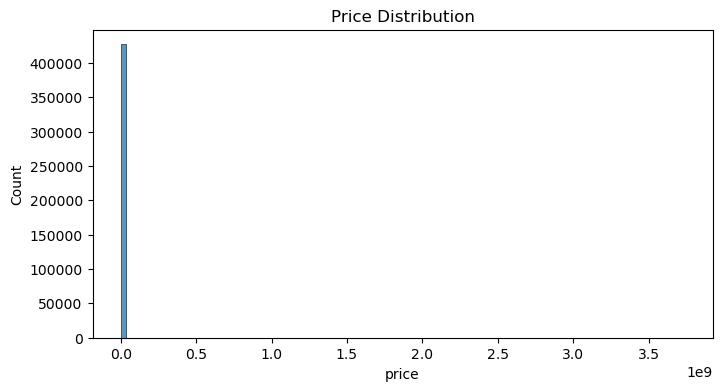

In [9]:
# Plot data

plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=100)
plt.title('Price Distribution')
plt.show()

## Data Preparation

Several data cleaning steps were applied to improve data quality:

- Removed listings with zero or unrealistic prices
- Filtered out extreme price outliers above $100,000
- Removed vehicles with unrealistic or missing year values
- Cleaned odometer values to remove missing and extreme values
- Dropped irrelevant columns such as ID and VIN

These steps ensure that the dataset is more suitable for modeling and reduces noise from invalid data entries.

In [10]:
# Data cleaning
# Remove bad price values

df_clean = df.copy()

# Remove zero or negative prices
df_clean = df_clean[df_clean['price'] > 0]

# Remove extreme outliers (above $100,000)
df_clean = df_clean[df_clean['price'] < 100000]

df_clean['price'].describe()

count    393288.000000
mean      18709.269533
std       14504.718754
min           1.000000
25%        7000.000000
50%       15000.000000
75%       27590.000000
max       99999.000000
Name: price, dtype: float64

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


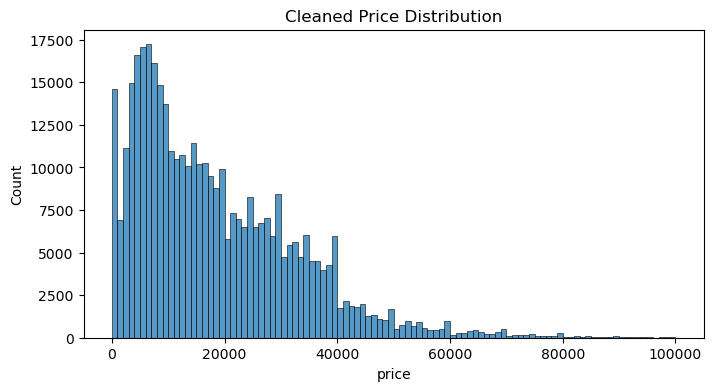

In [11]:
# Plot the price again

plt.figure(figsize=(8,4))
sns.histplot(df_clean['price'], bins=100)
plt.title('Cleaned Price Distribution')
plt.show()

In [12]:
# Clean year, missing year, unrealistic year

df_clean = df_clean[df_clean['year'].between(1990, 2022)]

In [13]:
# Clean odometer

df_clean = df_clean[df_clean['odometer'].notnull()]
df_clean = df_clean[df_clean['odometer'].between(0, 300000)]

In [14]:
# Drop useless columns

df_clean = df_clean.drop(columns=['id', 'VIN'])

In [15]:
# Checke the clean dataset

df_clean.shape
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 375431 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        375431 non-null  object 
 1   price         375431 non-null  int64  
 2   year          375431 non-null  float64
 3   manufacturer  363522 non-null  object 
 4   model         372001 non-null  object 
 5   condition     230738 non-null  object 
 6   cylinders     221357 non-null  object 
 7   fuel          373326 non-null  object 
 8   odometer      375431 non-null  float64
 9   title_status  368225 non-null  object 
 10  transmission  373931 non-null  object 
 11  drive         261810 non-null  object 
 12  size          104391 non-null  object 
 13  type          296403 non-null  object 
 14  paint_color   265165 non-null  object 
 15  state         375431 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 48.7+ MB


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

## Feature Engineering and Preparation

The dataset was prepared for modeling by selecting relevant numerical and categorical features. Numerical features include year and odometer, while categorical features include manufacturer, condition, fuel type, transmission, and vehicle type.

Missing values were handled using median imputation for numerical features and most frequent imputation for categorical features. Categorical variables were encoded using one-hot encoding to make them suitable for machine learning models.

In [16]:
# Select features

features = [
    'year',
    'manufacturer',
    'condition',
    'fuel',
    'odometer',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color',
    'state'
]

target = 'price'

df_model = df_clean[features + [target]].copy()

df_model.head()

,year,manufacturer,condition,fuel,odometer,title_status,transmission,drive,type,paint_color,state,price
27,2014.0,gmc,good,gas,57923.0,clean,other,NaN,pickup,white,al,33590
28,2010.0,chevrolet,good,gas,71229.0,clean,other,NaN,pickup,blue,al,22590
29,2020.0,chevrolet,good,gas,19160.0,clean,other,NaN,pickup,red,al,39590
30,2017.0,toyota,good,gas,41124.0,clean,other,NaN,pickup,red,al,30990
31,2013.0,ford,excellent,gas,128000.0,clean,automatic,rwd,truck,black,al,15000


In [17]:
# Transform log

df_model['log_price'] = np.log1p(df_model['price'])

In [18]:
# Split X and Y

X = df_model[features]
y = df_model['log_price']

In [19]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# Define numeric vs categorical 

numeric_features = ['year', 'odometer']

categorical_features = [col for col in features if col not in numeric_features]

In [21]:
# Build pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [22]:
# Model linear regression

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'odometer']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['manufacturer', 'condition',
                                                   'fuel', 'title_status',
                                                   'transmission', 'drive',
                                                   'type', 'paint_color',
                                                   'state'])])),
                ('model', LinearRegression())])

In [23]:
# Regression model evaluation

y_pred = linear_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

Linear Regression Results
RMSE: 0.9846078448830481
MAE: 0.4981064645265041
R2: 0.3416295917004263


In [24]:
# Ridge regression

ridge_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.1, 1.0, 10.0]
}

ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)

Best Ridge alpha: {'model__alpha': 10.0}


In [25]:
# Lasso regression

lasso_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

lasso_params = {
    'model__alpha': [0.001, 0.01, 0.1]
}

lasso_grid = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_)

Best Lasso alpha: {'model__alpha': 0.001}


In [26]:
# Compare models

def evaluate(model, name):
    pred = model.predict(X_test)
    print(f"\n{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("MAE:", mean_absolute_error(y_test, pred))
    print("R2:", r2_score(y_test, pred))

evaluate(linear_model, "Linear Regression")
evaluate(ridge_grid.best_estimator_, "Ridge")
evaluate(lasso_grid.best_estimator_, "Lasso")


Linear Regression
RMSE: 0.9846078448830481
MAE: 0.4981064645265041
R2: 0.3416295917004263

Ridge
RMSE: 0.9846291066700403
MAE: 0.4980601600586508
R2: 0.3416011574713168

Lasso
RMSE: 0.9902626857170838
MAE: 0.498904082965427
R2: 0.3340455147000361


Linear Regression and Ridge Regression performed nearly identically, with Linear Regression achieving the highest R² by a very small margin. Because the difference is negligible, either model could be used, but Linear Regression is a strong choice because it is simple and interpretable.

# Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [27]:
# Get feature importance 

feature_names = linear_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = linear_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values(by='coefficient', ascending=False)

coef_df.head(20)

,feature,coefficient
12,cat__manufacturer_ferrari,1.278399
55,cat__title_status_lien,0.700581
34,cat__manufacturer_porsche,0.668217
49,cat__fuel_diesel,0.615891
54,cat__title_status_clean,0.564405
4,cat__manufacturer_aston-martin,0.539019
39,cat__manufacturer_tesla,0.536611
72,cat__type_offroad,0.429728
58,cat__title_status_rebuilt,0.388593
45,cat__condition_good,0.365858


In [28]:
coef_df.tail(20)

,feature,coefficient
10,cat__manufacturer_chrysler,-0.245355
41,cat__manufacturer_volkswagen,-0.248104
75,cat__type_sedan,-0.255851
70,cat__type_hatchback,-0.258551
128,cat__state_or,-0.264569
22,cat__manufacturer_kia,-0.277672
11,cat__manufacturer_dodge,-0.291446
30,cat__manufacturer_mitsubishi,-0.344438
100,cat__state_fl,-0.354716
44,cat__condition_fair,-0.382190


In [29]:
# Chart
top_positive = coef_df.head(15)
top_negative = coef_df.tail(15)

print("Top Positive Features")
print(top_positive)

print("\nTop Negative Features")
print(top_negative)

Top Positive Features
                           feature  coefficient
12       cat__manufacturer_ferrari     1.278399
55          cat__title_status_lien     0.700581
34       cat__manufacturer_porsche     0.668217
49                cat__fuel_diesel     0.615891
54         cat__title_status_clean     0.564405
4   cat__manufacturer_aston-martin     0.539019
39         cat__manufacturer_tesla     0.536611
72               cat__type_offroad     0.429728
58       cat__title_status_rebuilt     0.388593
45             cat__condition_good     0.365858
0                        num__year     0.365551
24         cat__manufacturer_lexus     0.362470
46         cat__condition_like new     0.337845
74                cat__type_pickup     0.321605
43        cat__condition_excellent     0.319453

Top Negative Features
                          feature  coefficient
22          cat__manufacturer_kia    -0.277672
11        cat__manufacturer_dodge    -0.291446
30   cat__manufacturer_mitsubishi    -0.344438

<Figure size 1000x600 with 0 Axes>

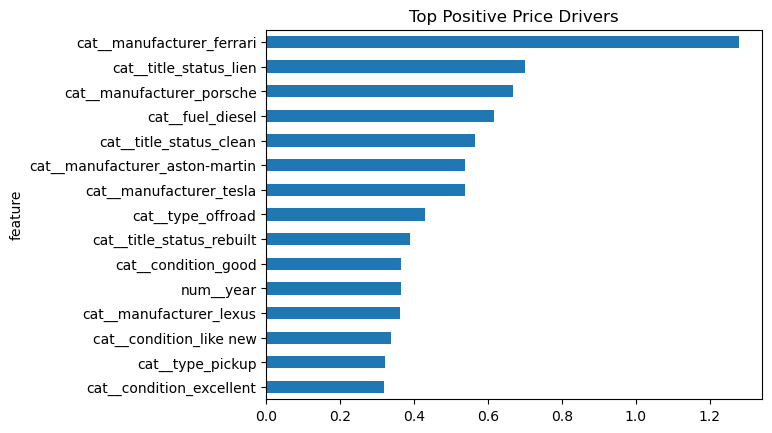

In [30]:

plt.figure(figsize=(10,6))
top_positive.sort_values('coefficient').plot(kind='barh', x='feature', y='coefficient', legend=False)
plt.title('Top Positive Price Drivers')
plt.show()

<Figure size 1000x600 with 0 Axes>

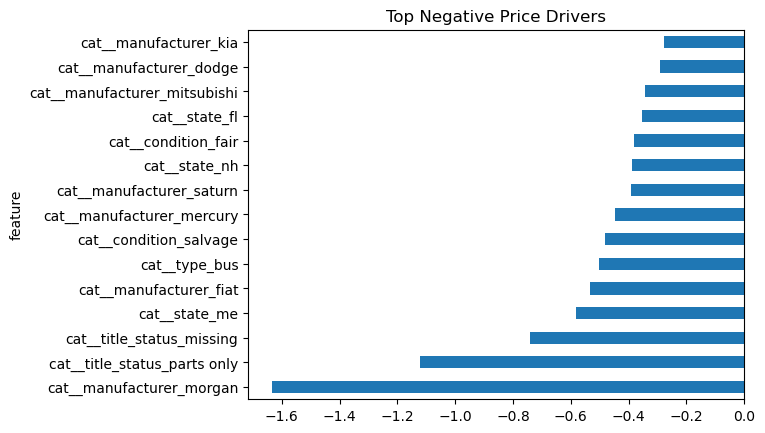

In [31]:

plt.figure(figsize=(10,6))
top_negative.sort_values('coefficient').plot(kind='barh', x='feature', y='coefficient', legend=False)
plt.title('Top Negative Price Drivers')
plt.show()

In [32]:
# Model comparison table

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, linear_model.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, ridge_grid.best_estimator_.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, lasso_grid.best_estimator_.predict(X_test)))
    ],
    'MAE': [
        mean_absolute_error(y_test, linear_model.predict(X_test)),
        mean_absolute_error(y_test, ridge_grid.best_estimator_.predict(X_test)),
        mean_absolute_error(y_test, lasso_grid.best_estimator_.predict(X_test))
    ],
    'R2': [
        r2_score(y_test, linear_model.predict(X_test)),
        r2_score(y_test, ridge_grid.best_estimator_.predict(X_test)),
        r2_score(y_test, lasso_grid.best_estimator_.predict(X_test))
    ]
})

results

,Model,RMSE,MAE,R2
0,Linear Regression,0.984608,0.498106,0.341630
1,Ridge,0.984629,0.498060,0.341601
2,Lasso,0.990263,0.498904,0.334046


## Evaluation summary

Three regression models were compared: Linear Regression, Ridge Regression, and Lasso Regression. Linear Regression achieved the highest R² score, although Ridge Regression performed almost identically. Lasso Regression performed slightly worse than the other two models.

Because Linear Regression provided the strongest performance while remaining easy to interpret, it was selected as the final model. The results suggest that vehicle price is influenced by a combination of numerical factors such as year and odometer reading, as well as categorical factors such as manufacturer, condition, transmission, fuel type, and vehicle type.

One limitation of the analysis is that the model explains only part of the variation in used car prices. This suggests that other factors not fully captured in the dataset, such as trim level, accident history, local market demand, and seller behavior, may also affect price.

## Key Findings

The model suggests that newer vehicles tend to have higher prices, while higher odometer readings tend to reduce price. In addition, certain manufacturers, fuel types, and vehicle types appear to be associated with higher resale values than others. Features related to vehicle condition and title status also influence pricing, indicating that buyers place value on reliability and lower risk.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Summary

This analysis used a cleaned dataset of used vehicle listings to identify factors associated with vehicle price. After preparing the data and comparing multiple regression models, Linear Regression was selected as the final model because it offered the best balance of performance and interpretability. The analysis shows that vehicle age, mileage, manufacturer, condition, and vehicle type all contribute to price differences. These findings can help dealerships improve inventory selection and pricing strategy.

## Recommendations for Used Car Dealers

Based on the analysis, used car dealers should consider the following strategies:

1. Prioritize newer vehicles with lower mileage, since these were among the strongest drivers of higher prices.
2. Focus on inventory with clean titles and better reported condition, as buyers appear to value lower-risk vehicles.
3. Stock manufacturers and vehicle types that show stronger value retention in the data.
4. Be cautious with older, high-mileage vehicles unless they can be acquired at a significant discount.
5. Improve listing quality by including complete and accurate vehicle details, since missing or unclear information may reduce buyer confidence and make pricing less effective.